In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold0_with_positions_steps_results.tsv", sep="\t")

fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold1_with_positions_steps_results.tsv", sep="\t")

fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold2_with_positions_steps_results.tsv", sep="\t")

fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
fold3 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold3_with_positions_steps_results.tsv", sep="\t")

fold3["fold"] = [3 for i in range(len(fold3))]

In [6]:
fold4 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold4_with_positions_steps_results.tsv", sep="\t")

fold4["fold"] = [4 for i in range(len(fold4))]

In [7]:
fold5 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold5_with_positions_steps_results.tsv", sep="\t")

fold5["fold"] = [5 for i in range(len(fold5))]

In [8]:
fold6 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold6_with_positions_steps_results.tsv", sep="\t")

fold6["fold"] = [6 for i in range(len(fold6))]

In [9]:
fold7 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold7_with_positions_steps_results.tsv", sep="\t")

fold7["fold"] = [7 for i in range(len(fold7))]

In [10]:
df = pd.concat([fold0, fold1, fold2,
                fold3, fold4, fold5,
                fold6, fold7], ignore_index=True)

In [11]:
len(df)

406

In [12]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [13]:
# selecting only sequences with a measurable contact enrichment
df = df[df['URQ_diff'] > 0.0]

In [14]:
len(df)

348

### saving sequences to fasta

In [ ]:
# import torch
# from Bio import SeqIO
# from Bio.Seq import Seq
# from Bio.SeqRecord import SeqRecord
# from pyfaidx import Fasta

In [ ]:
# fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
# sequence_dir = "/scratch1/smaruj/suppressing_CTCFs/results"
# output_fasta = "combined_sequences.fasta"

In [ ]:
genome = Fasta(fasta_file)

In [ ]:
def ohe_to_seq(tensor):
    base_order = ['A', 'C', 'G', 'T']
    tensor = tensor.permute(1, 0)
    indices = torch.argmax(tensor, dim=1)
    return ''.join([base_order[i.item()] for i in indices])

In [ ]:
bin_size = 2048
cropping_applied = 64
padding_bins = 2
padding = padding_bins * bin_size

slice_0_bins = [256]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [ ]:
records = []
for i, row in df.iterrows():
    chrom = row['chrom']
    centered_start = int(row['centered_start'])
    centered_end = int(row['centered_end'])
    start = centered_start + slice_0_start
    end = centered_start + slice_0_end
    fold = row['fold']

    # (1) Get 60 bp upstream
    upstream = genome[chrom][start - 60:start].seq.upper()

    # (2) Read .pt file and decode
    seq_path = f"{sequence_dir}/fold{fold}/{chrom}_{centered_start}_{centered_end}_slice.pt"
    ohe_tensor = torch.load(seq_path)  # shape: (2048, 4)
    seq_string = ohe_to_seq(ohe_tensor.squeeze(0))

    # (3) Get 60 bp downstream
    downstream = genome[chrom][end:end + 60].seq.upper()

    # (4) Combine all parts
    full_seq = upstream + seq_string + downstream

    # (5) Create FASTA record
    header = f"{chrom}_{centered_start}_{centered_end}"
    record = SeqRecord(Seq(full_seq), id=header, description="")
    records.append(record)

# with open(f"{sequence_dir}/{output_fasta}", "w") as out_f:
#     SeqIO.write(records, out_f, "fasta")

# print(f"✅ Done. {len(records)} sequences written to {output_fasta}")

### saving the original sequences

In [ ]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
sequence_dir = "/scratch1/smaruj/suppressing_CTCFs/results"
output_fasta = "OG_combined_sequences.fasta"

In [ ]:
records = []
for i, row in df.iterrows():
    chrom = row['chrom']
    centered_start = int(row['centered_start'])
    centered_end = int(row['centered_end'])
    start = centered_start + slice_0_start
    end = centered_start + slice_0_end
    fold = row['fold']

    og_sequence = genome[chrom][start - 60:end + 60].seq.upper()

    # Create FASTA record
    header = f"{chrom}_{centered_start}_{centered_end}"
    record = SeqRecord(Seq(og_sequence), id=header, description="")
    records.append(record)

with open(f"{sequence_dir}/{output_fasta}", "w") as out_f:
    SeqIO.write(records, out_f, "fasta")

print(f"✅ Done. {len(records)} sequences written to {output_fasta}")

In [ ]:
# for i, row in df.iterrows():
#     chrom = row['chrom']
#     centered_start = int(row['centered_start'])
#     centered_end = int(row['centered_end'])
#     start = centered_start + slice_0_start
#     end = centered_start + slice_0_end
#     fold = row['fold']

#     og_sequence = genome[chrom][start - 60:end + 60].seq.upper()

#     # Create FASTA record
#     header = f"{chrom}_{centered_start}_{centered_end}"
#     record = SeqRecord(Seq(og_sequence), id=header, description="")

#     # (6) Write this sequence to its own FASTA file
#     out_path = f"{sequence_dir}/OG_seqs_fasta/{header}.fasta"
#     with open(out_path, "w") as out_f:
#         SeqIO.write(record, out_f, "fasta")

# print(f"✅ Done. {len(df)} separate FASTA files written to {sequence_dir}")

### Plots

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
from scipy.stats import ttest_rel, wilcoxon

### How are the URQ mean distributions different?

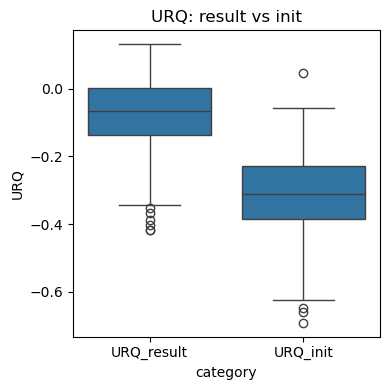

In [17]:
# --- Reshape for plotting ---
urq_df = pd.melt(
    df,
    value_vars=["URQ_result", "URQ_init"],
    var_name="category",
    value_name="URQ"
)

# --- Boxplot ---
plt.figure(figsize=(4,4))
sns.boxplot(data=urq_df, x="category", y="URQ")
plt.title("URQ: result vs init")
plt.tight_layout()
plt.show()

In [18]:
# --- Statistical tests ---
t_stat, t_p = ttest_rel(df["URQ_result"], df["URQ_init"])
w_stat, w_p = wilcoxon(df["URQ_result"], df["URQ_init"])

print(f"Paired t-test: p={t_p:.3e}")
print(f"Wilcoxon: p={w_p:.3e}")

Paired t-test: p=2.316e-205
Wilcoxon: p=8.608e-59


### Are the flanks of the newly added CTCFs stronger than the old ones?

In [19]:
plot_df = pd.melt(
    df,
    value_vars=[
        "avg_orig_left_fimo_scores",
        "avg_new_left_fimo_scores",
        "avg_orig_right_fimo_scores",
        "avg_new_right_fimo_scores"
    ],
    var_name="category",
    value_name="score"
)

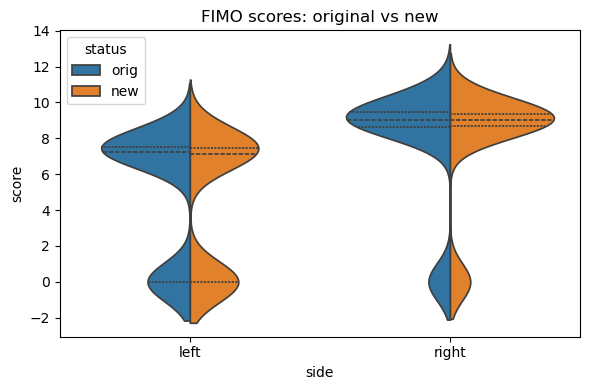

In [20]:
# Split into side (left/right) and status (orig/new)
plot_df["side"] = plot_df["category"].str.extract(r"(left|right)")
plot_df["status"] = plot_df["category"].str.extract(r"(orig|new)")

# --- Violin plot ---
plt.figure(figsize=(6,4))
sns.violinplot(
    data=plot_df,
    x="side",
    y="score",
    hue="status",
    split=True,
    inner="quartile"
)
plt.title("FIMO scores: original vs new")
plt.tight_layout()
plt.show()

In [21]:
from scipy.stats import wilcoxon

In [22]:
# --- Statistical tests ---
# Left: orig vs new
left_stat, left_p = wilcoxon(
    df["avg_orig_left_fimo_scores"],
    df["avg_new_left_fimo_scores"]
)

# Right: orig vs new
right_stat, right_p = wilcoxon(
    df["avg_orig_right_fimo_scores"],
    df["avg_new_right_fimo_scores"]
)

print(f"Left FIMO: Wilcoxon p={left_p:.3e}")
print(f"Right FIMO: Wilcoxon p={right_p:.3e}")

Left FIMO: Wilcoxon p=5.148e-03
Right FIMO: Wilcoxon p=9.387e-02


### Is the GC content changed?

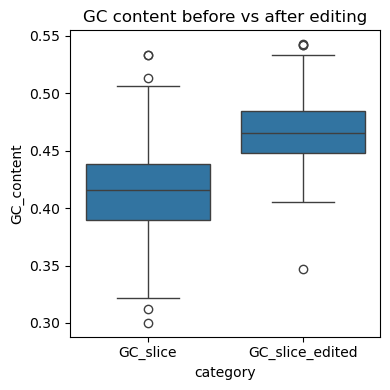

In [23]:
# --- Reshape for plotting ---
gc_df = pd.melt(
    df,
    value_vars=["GC_slice", "GC_slice_edited"],
    var_name="category",
    value_name="GC_content"
)

# --- Boxplot ---
plt.figure(figsize=(4,4))
sns.boxplot(data=gc_df, x="category", y="GC_content")
plt.title("GC content before vs after editing")
plt.tight_layout()
plt.show()

In [24]:
from scipy.stats import ttest_rel, wilcoxon

# Paired t-test
t_stat, t_p = ttest_rel(df["GC_slice"], df["GC_slice_edited"])
print(f"Paired t-test: p={t_p:.3e}")

# Wilcoxon
w_stat, w_p = wilcoxon(df["GC_slice"], df["GC_slice_edited"])
print(f"Wilcoxon: p={w_p:.3e}")

Paired t-test: p=5.620e-131
Wilcoxon: p=1.597e-58


### Orientations of the original CTCF motifs

In [25]:
import ast

# Convert stringified sets into real Python sets of tuples
df["orig_CTCFs_coord"] = df["orig_CTCFs_coord"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["new_CTCFs_coord"] = df["new_CTCFs_coord"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [26]:
# Canonicalize function
def canonicalize(ori):
    # Flip strand: replace + <-> -
    flipped = ori.replace("+", "x").replace("-", "+").replace("x", "-")
    # Pick lexicographically smaller string as canonical
    return min(ori, flipped)

In [27]:
from collections import Counter

In [28]:
# Collect canonical orientation clusters for original CTCFs
orientation_clusters = []

for _, row in df.iterrows():
    orig_sites = sorted(list(row["orig_CTCFs_coord"]), key=lambda x: x[0])
    if len(orig_sites) >= 2:
        cluster = ''.join([s[2] for s in orig_sites])
        orientation_clusters.append(canonicalize(cluster))

# Count each unique canonical cluster
cluster_counts = Counter(orientation_clusters)


In [29]:
clusters, counts = zip(*cluster_counts.most_common())

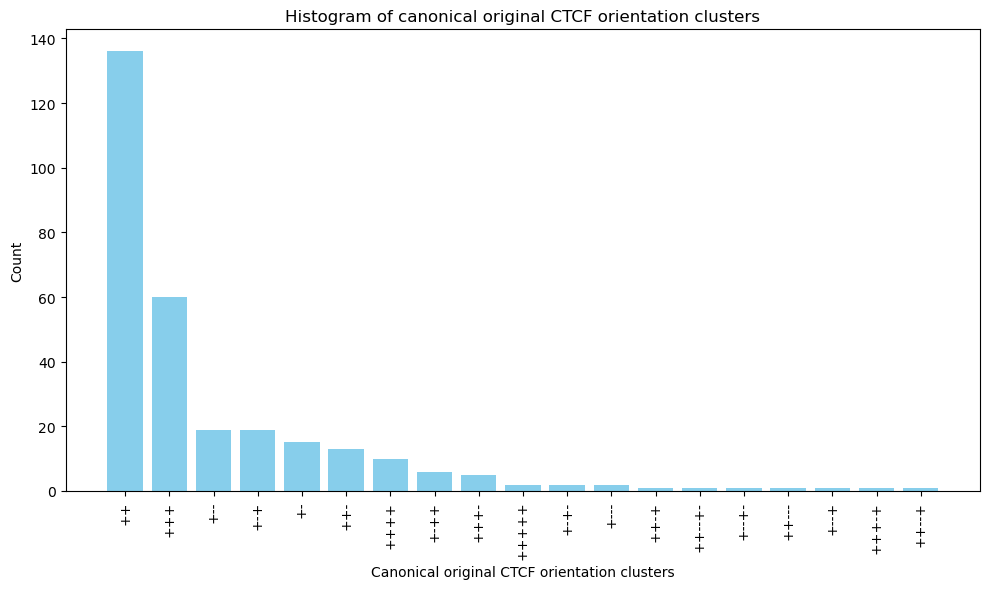

In [30]:
# Plot histogram
plt.figure(figsize=(10, 6))
plt.bar(clusters, counts, color='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Canonical original CTCF orientation clusters")
plt.ylabel("Count")
plt.title("Histogram of canonical original CTCF orientation clusters")
plt.tight_layout()
plt.show()

### How many of the new CTCFs have the opposite orienatation to the old CTCFs?

In [31]:
df[['orig_CTCFs_coord', 'new_CTCFs_coord']]

,orig_CTCFs_coord,new_CTCFs_coord
0,"{(1535, 1554, -), (1448, 1467, +), (1446, 1465...","{(319, 338, +), (1338, 1357, -), (87, 106, -)}"
1,"{(1400, 1419, +), (1467, 1486, +), (514, 533, ...","{(1174, 1193, -), (742, 761, -)}"
2,"{(218, 237, +), (1726, 1745, +), (1054, 1073, ...","{(460, 479, -), (1899, 1918, -), (1497, 1516, -)}"
3,"{(949, 968, +), (1769, 1788, +), (1026, 1045, +)}","{(1296, 1315, +), (1123, 1142, +), (244, 263, ..."
4,"{(517, 536, +), (1148, 1167, +)}","{(781, 800, -), (288, 307, -)}"
...,...,...
397,"{(450, 469, -)}","{(313, 332, -), (484, 503, +)}"
398,"{(483, 502, -), (1971, 1990, +), (344, 363, -)}","{(1464, 1483, -)}"
400,"{(396, 415, -)}","{(30, 49, +), (680, 699, +), (10, 29, -)}"
401,"{(241, 260, +), (1949, 1968, +), (1142, 1161, -)}","{(1279, 1298, -)}"


In [32]:
import ast

# Convert stringified sets into real Python sets of tuples
df["orig_CTCFs_coord"] = df["orig_CTCFs_coord"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["new_CTCFs_coord"] = df["new_CTCFs_coord"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [34]:
def majority_orientation(coords):
    """Return majority orientation ('+' or '-') from a set of (start, end, orientation)."""
    if not coords:  # empty set
        return None
    orientations = [o for _, _, o in coords]
    plus_count = orientations.count("+")
    minus_count = orientations.count("-")
    return "+" if plus_count >= minus_count else "-"

def count_opposite(coords, majority):
    """Count how many coords have opposite orientation to majority."""
    if not coords or majority is None:
        return 0
    return sum(1 for _, _, o in coords if o != majority)

In [35]:
# Add majority orientation column
df["orig_main_orientation"] = df["orig_CTCFs_coord"].apply(majority_orientation)

In [36]:
# Count opposite orientations in new coords
df["new_opposite_count"] = df.apply(
    lambda row: count_opposite(row["new_CTCFs_coord"], row["orig_main_orientation"]),
    axis=1
)

In [37]:
# Total new CTCFs
df["new_total_count"] = df["new_CTCFs_coord"].apply(lambda coords: len(coords) if coords else 0)

In [38]:

# Fraction of opposite
df["new_opposite_fraction"] = df.apply(
    lambda row: row["new_opposite_count"] / row["new_total_count"] if row["new_total_count"] > 0 else 0,
    axis=1
)

In [ ]:
df

/tmp/SLURM_1764243/ipykernel_3634349/2994024097.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


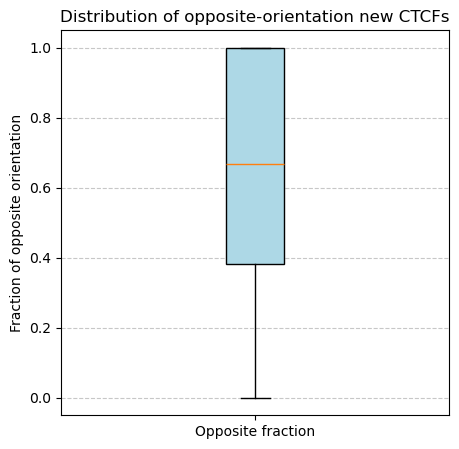

In [40]:
plt.figure(figsize=(5,5))
bp = plt.boxplot(
    df["new_opposite_fraction"].dropna(),
    labels=["Opposite fraction"],
    patch_artist=True  # allows filling the box
)

# Set box colors
for box in bp['boxes']:
    box.set(facecolor='lightblue')

plt.ylabel("Fraction of opposite orientation")
plt.title("Distribution of opposite-orientation new CTCFs")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### Are the new CTCFs are placed in between the original motifs and with the oposite orientation?

In [42]:
from scipy.stats import binomtest

def analyze_ctcf_triplets(df, orig_col="orig_CTCFs_coord", new_col="new_CTCFs_coord"):
    triplet_patterns = []
    opposite_count = 0
    total_between = 0

    for _, row in df.iterrows():
        orig_sites = sorted(list(row[orig_col]), key=lambda x: x[0])  # sort by start
        new_sites = sorted(list(row[new_col]), key=lambda x: x[0])

        # Loop through new sites and check if they fall between two originals
        for ns in new_sites:
            n_start, n_end, n_strand = ns
            for i in range(len(orig_sites) - 1):
                o1 = orig_sites[i]
                o2 = orig_sites[i+1]
                if o1[1] < n_start < o2[0]:  # falls between
                    pattern = o1[2] + n_strand + o2[2]
                    # Only consider triplets where first and third strands are the same
                    if o1[2] == o2[2]:
                        total_between += 1
                        triplet_patterns.append(pattern)
                        # Count as opposite if middle strand differs from flanks
                        if n_strand != o1[2]:
                            opposite_count += 1
                    break

    # Compute proportion and binomial test
    if total_between > 0:
        prop_opposite = opposite_count / total_between
        pval = binomtest(opposite_count, total_between, p=0.5, alternative="greater").pvalue
    else:
        prop_opposite, pval = None, None

    return {
        "total_between": total_between,
        "opposite_count": opposite_count,
        "prop_opposite": prop_opposite,
        "pval": pval,
        "triplet_patterns": triplet_patterns
    }


In [43]:
result = analyze_ctcf_triplets(df)

In [44]:
for key in result:
    print(key, result[key])

total_between 265
opposite_count 163
prop_opposite 0.6150943396226415
pval 0.0001075309439870323
triplet_patterns ['---', '-+-', '---', '+-+', '+-+', '+-+', '+-+', '+++', '+++', '+-+', '-+-', '-+-', '---', '-+-', '---', '---', '-+-', '---', '-+-', '-+-', '---', '-+-', '-+-', '---', '-+-', '---', '---', '+++', '+-+', '---', '-+-', '+-+', '+-+', '-+-', '-+-', '+-+', '+-+', '+-+', '+-+', '+-+', '+-+', '+++', '+-+', '+-+', '---', '+-+', '---', '+-+', '+-+', '+++', '+-+', '-+-', '-+-', '+++', '---', '-+-', '---', '-+-', '---', '-+-', '-+-', '-+-', '---', '-+-', '+-+', '---', '+-+', '---', '---', '-+-', '+-+', '---', '---', '-+-', '---', '---', '-+-', '---', '+-+', '+-+', '+++', '+++', '---', '+++', '+-+', '+++', '---', '-+-', '-+-', '---', '-+-', '---', '---', '+-+', '+++', '+-+', '+-+', '+-+', '+++', '+-+', '+-+', '+++', '---', '+-+', '+-+', '+-+', '+++', '+-+', '+-+', '+-+', '-+-', '-+-', '-+-', '-+-', '+++', '+-+', '---', '+-+', '+++', '+-+', '---', '---', '+++', '+-+', '-+-', '+-+', '+-

In [45]:
from collections import Counter

# Count triplet patterns
pattern_counts = Counter(result["triplet_patterns"])

In [46]:
pattern_df = pd.DataFrame.from_dict(pattern_counts, orient="index", columns=["count"]).reset_index()
pattern_df = pattern_df.rename(columns={"index": "pattern"}).sort_values("count", ascending=False)

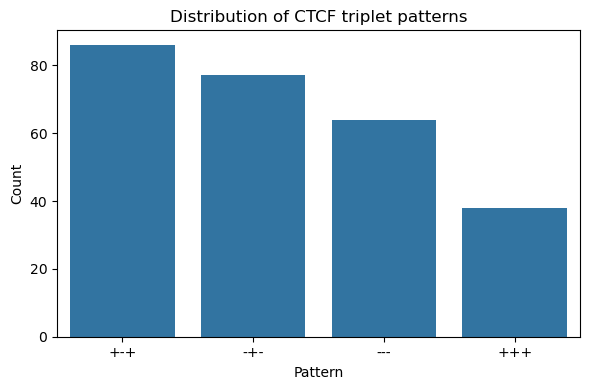

In [47]:
# Barplot
plt.figure(figsize=(6,4))
sns.barplot(data=pattern_df, x="pattern", y="count")
plt.title("Distribution of CTCF triplet patterns")
plt.ylabel("Count")
plt.xlabel("Pattern")
plt.tight_layout()

plt.savefig("suppressing_triplets_orientations.svg", format='svg')

plt.show()

### Is the orientation of the new CTCF motifs convergent with existing CTCFs (suggesting loop formation)?

In [ ]:
orientations = []
observed_pairs_total = 0
total_pairs_total = 0

for _, row in df.iterrows():
    new_sites = sorted(list(row["new_CTCFs_coord"]), key=lambda x: x[0])
    old_sites = sorted(list(row["orig_CTCFs_coord"]), key=lambda x: x[0])
    all_sites = sorted([(s[0], 'new', s) for s in new_sites] + [(s[0], 'old', s) for s in old_sites])
    
    for i, (pos, typ, site) in enumerate(all_sites):
        if typ != 'new':
            continue
        
        # left neighbor
        for j in range(i-1, -1, -1):
            if all_sites[j][1] == 'old':
                left_old = all_sites[j][2]
                orientations.append(site[2] + left_old[2])
                total_pairs_total += 1
                if site[2] == "+" and left_old[2] == "-" and site[0] < left_old[0]:
                    observed_pairs_total += 1
                elif site[2] == "-" and left_old[2] == "+" and site[0] > left_old[0]:
                    observed_pairs_total += 1
                break  # stop at the first old neighbor
        
        # right neighbor
        for j in range(i+1, len(all_sites)):
            if all_sites[j][1] == 'old':
                right_old = all_sites[j][2]
                orientations.append(site[2] + right_old[2])
                total_pairs_total += 1
                if site[2] == "+" and right_old[2] == "-" and site[0] < right_old[0]:
                    observed_pairs_total += 1
                elif site[2] == "-" and right_old[2] == "+" and site[0] > right_old[0]:
                    observed_pairs_total += 1
                break

In [ ]:
pairs_df = pd.DataFrame(orientations, columns=["orientation"])

In [ ]:
len(pairs_df)

In [ ]:
pairs_counts = pairs_df["orientation"].value_counts().reset_index()
pairs_counts.columns = ["orientation", "count"]

plt.figure(figsize=(5,4))
sns.barplot(data=pairs_counts, x="orientation", y="count", palette="pastel")
plt.title("Neighbor CTCF pair orientations (new–old)")
plt.ylabel("Count")
plt.xlabel("Orientation")
plt.tight_layout()
plt.show()

In [ ]:
# Count the number of "+-" neighbor pairs
num_plus_minus = orientations.count("+-")
total_orientations = len(orientations)

# Proportion
prop_plus_minus = num_plus_minus / total_orientations
print(f'"+-" count: {num_plus_minus}, proportion: {prop_plus_minus:.3f}')

# Binomial test against null proportion 0.25
pval = binomtest(num_plus_minus, n=total_orientations, p=0.25, alternative='two-sided').pvalue
print(f'Binomial test p-value: {pval:.3e}')

In [ ]:
# Count loop-forming pairs: "+-" and "-+"
num_loop_pairs = orientations.count("+-") + orientations.count("-+")
total_orientations = len(orientations)

# Proportion of loop-forming orientations
prop_loop_pairs = num_loop_pairs / total_orientations
print(f'Loop-forming pairs (+- and -+) count: {num_loop_pairs}, proportion: {prop_loop_pairs:.3f}')

# Binomial test against null proportion 0.5
pval_loop = binomtest(num_loop_pairs, n=total_orientations, p=0.5, alternative='greater').pvalue
print(f'Binomial test p-value (favoring loop-forming): {pval_loop:.3e}')